# 01 - Dataset Exploration

**Objective:** Explore the 6 raw datasets (`c3gd`, `fsc22`, `rodopi`, `esc50_hf`, `rfcx_frugalai`, `sensing_forest`) and the frozen v1 manifest to understand class balance, per-source contribution, and duration statistics.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


## Load the frozen v1 master manifest

In [2]:
master = pd.read_csv(ML_ROOT / 'datasets' / 'v1' / 'master_v1.csv', low_memory=False)
print('Total segments:', len(master))
print('Total recordings:', master['original_recording_id'].nunique())
master.head()

Total segments: 58918
Total recordings: 1975


,sample_id,dataset_id,original_recording_id,class,segment_index,duration,sample_rate,channels,processed_path,quality_status,event_id,platform_id,cartridge_id,mic_id,fsc22_class_name,event_interval_id,interval_start,interval_end,esc50_category
0,c3gd_16-oh_farm-7mm_Mauser-ALICE-chv3xlV_eY8m-...,c3gd,c3gd_oh_farm_16-oh_farm-7mm_Mauser-ALICE-chv3x...,gunshot,0,1.0,16000,1,datasets/processed/c3gd_16-oh_farm-7mm_Mauser-...,OK,oh_farm,7mm_Mauser,ppu_rl_757m_139,ALICE,NaN,NaN,NaN,NaN,NaN
1,c3gd_17-nj_farm_2-sw_mp_fpc_compliant-bluebell...,c3gd,c3gd_nj_farm_2_17-nj_farm_2-sw_mp_fpc_complian...,gunshot,0,1.0,16000,1,datasets/processed/c3gd_17-nj_farm_2-sw_mp_fpc...,OK,nj_farm_2,sw_mp_fpc_compliant,gdc_135gr_hp,bluebell_DOM2,NaN,NaN,NaN,NaN,NaN
2,c3gd_17-oh_farm-sig_P320-DAVE-RnHmQd98noYs-11_...,c3gd,c3gd_oh_farm_17-oh_farm-sig_P320-DAVE-RnHmQd98...,gunshot,0,1.0,16000,1,datasets/processed/c3gd_17-oh_farm-sig_P320-DA...,OK,oh_farm,sig_P320,NaN,DAVE,NaN,NaN,NaN,NaN,NaN
3,c3gd_2-oh_farm-custom_ar15_300BLK_rb-DAVE-i1jO...,c3gd,c3gd_oh_farm_2-oh_farm-custom_ar15_300BLK_rb-D...,gunshot,0,1.0,16000,1,datasets/processed/c3gd_2-oh_farm-custom_ar15_...,OK,oh_farm,custom_ar15_300BLK_rb,winchester_ss_300BLK_200,DAVE,NaN,NaN,NaN,NaN,NaN
4,c3gd_13-nj_farm-savage_mh110-DAVE-3fPPqTzCQ_WZ...,c3gd,c3gd_nj_farm_13-nj_farm-savage_mh110-DAVE-3fPP...,gunshot,0,1.0,16000,1,datasets/processed/c3gd_13-nj_farm-savage_mh11...,OK,nj_farm,savage_mh110,sb_ta_65CD_140,DAVE,NaN,NaN,NaN,NaN,NaN


## Class distribution

class
background    55069
chainsaw       3407
gunshot         442
Name: count, dtype: int64


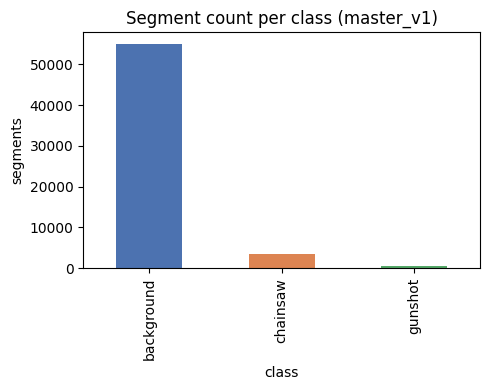

In [3]:
class_counts = master['class'].value_counts()
print(class_counts)
fig, ax = plt.subplots(figsize=(5,4))
class_counts.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Segment count per class (master_v1)')
ax.set_ylabel('segments')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_class_distribution.png', dpi=120)
plt.show()

## Per-dataset contribution

class           background  chainsaw  gunshot
dataset_id                                   
c3gd                     0         0      100
esc50_hf              3764       356        0
fsc22                 6665       669      342
rfcx_frugalai         1246       741        0
rodopi               25056      1641        0
sensing_forest       18338         0        0


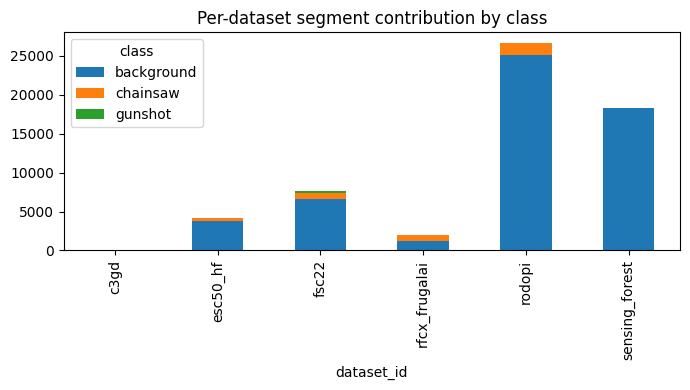

In [4]:
ct = pd.crosstab(master['dataset_id'], master['class'])
print(ct)
fig, ax = plt.subplots(figsize=(7,4))
ct.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Per-dataset segment contribution by class')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_per_dataset_contribution.png', dpi=120)
plt.show()

## Duration statistics

In [5]:
print(master['duration'].describe())
print('Total duration (hours):', master['duration'].sum()/3600)

count    58918.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: duration, dtype: float64
Total duration (hours): 16.36611111111111


## Conclusion

The dataset is heavily background-dominated (as expected for real forest acoustic monitoring), with chainsaw the second-most represented class and gunshot the rarest. This motivates class-weighted training in notebooks 04/05/06. See `reports/DATASET_V1_REPORT.md` for the full per-dataset breakdown and labeling-mapping documentation.